## Sales Prediction using Multiple Linear Regression (Built from Scratch)

Predicting product Sales from advertising spend (TV, Radio, Newspaper) plus two engineered features (budget_tier, campaign_quarter), implementing the Normal Equation manually and validating against scikit-learn.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 1. Load Data

In [4]:
df = pd.read_csv('Datasets/Advertising_with_ordinal.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,budget_tier,campaign_quarter,Sales
0,1,230.1,37.8,69.2,High,Q4,22.1
1,2,44.5,39.3,45.1,Low,Q1,10.4
2,3,17.2,45.9,69.3,Low,Q2,9.3
3,4,151.5,41.3,58.5,High,Q3,18.5
4,5,180.8,10.8,58.4,High,Q4,12.9


### 2. Exploratory Data Analysis


Text(0, 0.5, 'Sales')

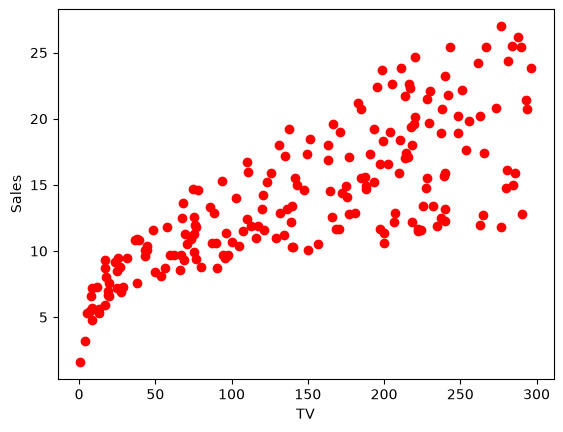

In [5]:
plt.scatter(df['TV'], df['Sales'], color='Red', label ='TV')
plt.xlabel('TV')
plt.ylabel('Sales')

Text(0, 0.5, 'Sales')

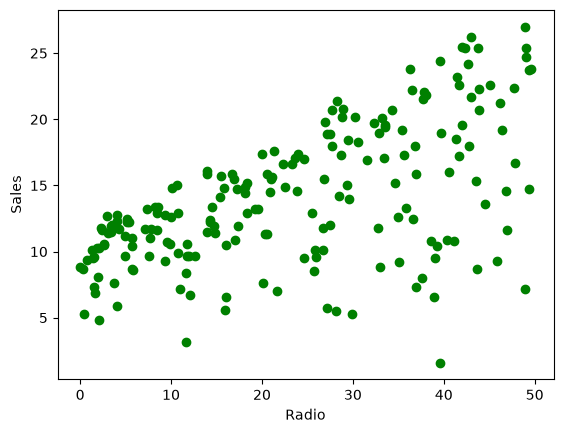

In [6]:
plt.scatter(df['Radio'], df['Sales'], color='Green', label ='Radio')
plt.xlabel('Radio')
plt.ylabel('Sales')

Text(0, 0.5, 'Sales')

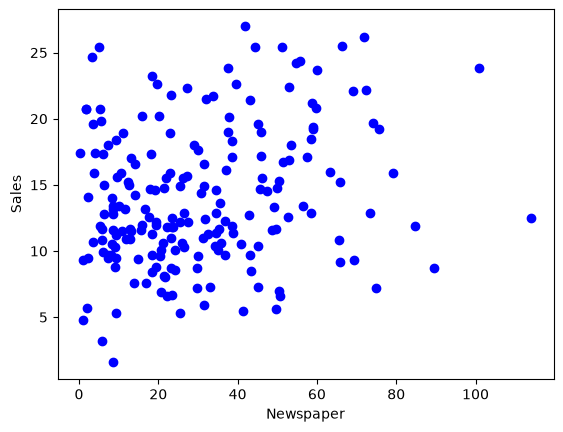

In [7]:
plt.scatter(df['Newspaper'], df['Sales'], color='Blue', label ='Newspaper')
plt.xlabel('Newspaper')
plt.ylabel('Sales')

In [8]:
df.info

<bound method DataFrame.info of      Unnamed: 0     TV  Radio  Newspaper budget_tier campaign_quarter  Sales
0             1  230.1   37.8       69.2        High               Q4   22.1
1             2   44.5   39.3       45.1         Low               Q1   10.4
2             3   17.2   45.9       69.3         Low               Q2    9.3
3             4  151.5   41.3       58.5        High               Q3   18.5
4             5  180.8   10.8       58.4        High               Q4   12.9
..          ...    ...    ...        ...         ...              ...    ...
195         196   38.2    3.7       13.8         Low               Q4    7.6
196         197   94.2    4.9        8.1         Low               Q2    9.7
197         198  177.0    9.3        6.4      Medium               Q1   12.8
198         199  283.6   42.0       66.2        High               Q4   25.5
199         200  232.1    8.6        8.7      Medium               Q1   13.4

[200 rows x 7 columns]>

### 3. Train/Test Split

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

In [10]:
X = df.iloc[:, 1:6]
Y = df.iloc[:, -1]


In [11]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [12]:
x_test.shape

(40, 5)

In [13]:
df['budget_tier'].unique()

<StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str

### 4. Encoding

In [14]:
transformer = ColumnTransformer(transformers= [
    ('tnf1', OrdinalEncoder(categories=[['Low', 'Medium', 'High']]), ['budget_tier']),
    ('tnf2', OneHotEncoder(drop='first'), ['campaign_quarter']),],
    remainder='passthrough'
)

In [15]:
X_train = transformer.fit_transform(x_train)
X_test = transformer.transform(x_test)

### 5. Model (from Scratch)

In [16]:
class Lr:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None 
    
    def fit(self, x_train, y_train):
        x_train = np.insert(x_train, 0, 1, axis=1)
        
        beta = np.linalg.inv(np.dot(x_train.T, x_train)).dot(x_train.T).dot(y_train)
        
        self.coef_ = beta[1:]
        self.intercept_ = beta[0]
    
    def predict(self, x_test):
        y_pred = np.dot(x_test, self.coef_) + self.intercept_
        return y_pred

In [17]:
lr = Lr()

In [18]:
lr.fit(X_train, y_train)

In [19]:
y_pred = lr.predict(X_test)

### 6. Evaluation

In [20]:
from sklearn.metrics import r2_score, mean_absolute_error

In [21]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R-squared Score:", r2) 
print("Mean Absolute Error:", mae)

R-squared Score: 0.9041560798039935
Mean Absolute Error: 1.4182154680835453


### Model Performance Interpretation

* **R² (Coefficient of Determination) = 0.90**
  * **What it means:** This tells us that about **0.90** of the variance/variation in our target variable is explained by our model's features. The closer this number is to 1.0 (or 100%), the better our model fits the data. 

* **MAE (Mean Absolute Error) = 1.42**
  * **What it means:** On average, our model's predictions are off by about **1.42** from the actual values. Unlike other metrics, MAE gives us a direct, real-world sense of the average error size.


### 7. Residual Analysis

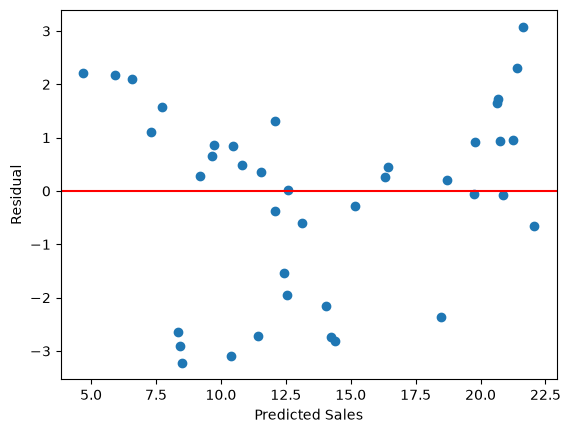

In [22]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel('Predicted Sales')
plt.ylabel('Residual')
plt.show()

In [28]:
pd.DataFrame({'Feature': ['budget_tier','Q2','Q3','Q4','TV','Radio','Newspaper'], 'Coefficient': lr.coef_})

,Feature,Coefficient
0,budget_tier,-0.750811
1,Q2,0.050224
2,Q3,0.290588
3,Q4,0.464369
4,TV,0.051272
5,Radio,0.192161
6,Newspaper,0.005837


### 8. Comparison with Scikit-learn

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
LR = LinearRegression()

In [25]:
LR.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[-0.75, 0.05, 0.29,..., 0.05, 0.19, 0.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.392
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[1064.58, 272.75, 161.52,..., 5.68, 3.78, 3.24]"


In [26]:
sk_y_pred = LR.predict(X_test)

In [27]:
sk_r2 = r2_score(y_test, sk_y_pred)
mae = mean_absolute_error(y_test, sk_y_pred)

print("R-squared Score:", sk_r2) 
print("Mean Absolute Error:", mae)

R-squared Score: 0.9041560798039894
Mean Absolute Error: 1.4182154680835346
